In [1]:
import sys
path_lock = False
if not path_lock:
    sys.path.append("../")
    path_lock = True
    
import numpy as np
import ffiting as ff

# Exponential

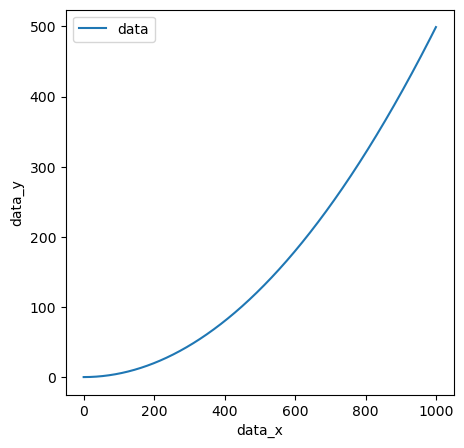

In [2]:
data_x = np.arange(0, 1000)
coeffs_poly = [0, 0, 0.0005]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)

ff.multi_plot(ff.PlotRequest(data_ideal,"data"))

## Use normal DSB

'Polynomial coeffs were calculated'

array([ 3.70618618e-01, -7.86204666e-03,  5.25796305e-04, -1.65505129e-08])

'The balance was formed:'

-a0 - a2 + 0.370618617948731

-H*a1 - H*a2*a3 - 0.00786204666109295*H

...

'Expression generated:'

a0 + a1*x + a2*exp(a3*x)

'Coeffs: [-1.1792769e+05  1.1128218e+01  1.1792806e+05 -9.4431132e-05]'

'Metrics:'

Residual SE: 1.181
Mean SE: 1.393
Linear Div: 971.569
Standard Div: 149.895
Standard Err: 4.740
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


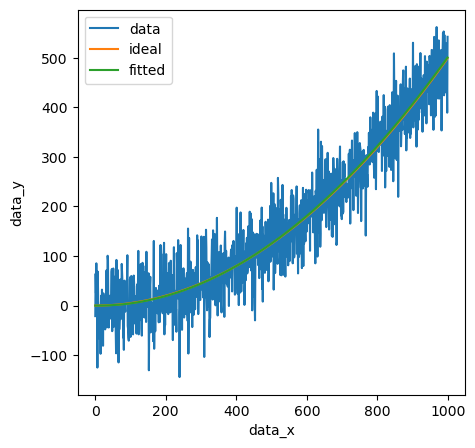

In [3]:
model = ff.Models.exponential(ff.FittingModes.DSB)
model.options.echo_on = True
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use coeffs calculated in Maple

In [4]:
display(ff.poly_fit(data_ideal, 3).coeffs[::-1])    

array([0.    , 0.    , 0.0005, 0.    ])

'Metrics:'

Residual SE: 0.031
Mean SE: 0.001
Linear Div: 20.382
Standard Div: 148.908
Standard Err: 4.709
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


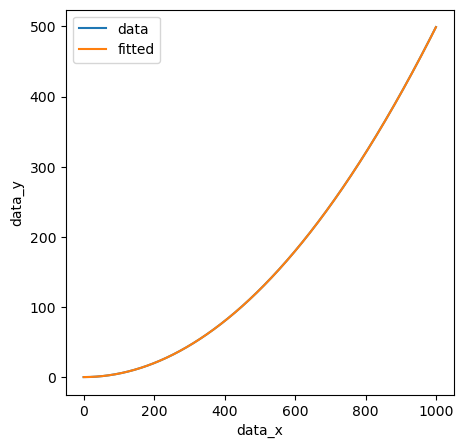

In [5]:
maple_coeffs = [-4.048433295*10**9, 2012.072142, 4.048433295*10**9,  -4.970001961*10**(-7)]
def maple_model(x: float) -> float:
    return maple_coeffs[0] + maple_coeffs[1] * x + maple_coeffs[2] * np.exp(maple_coeffs[3] * x)

data_fitted = np.zeros(data_x.size)
for i in np.arange(data_x.size):
    data_fitted[i] = maple_model(data_x[i])

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use programmatic DSBI

In [15]:
model = ff.Models.exponential(ff.FittingModes.DSBI)
model.options.rank = 4
model.options.dsbi_h = 1.002
model.options.echo_on = True
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

'Polynomial coeffs were calculated'

array([ 4.35639270e+00, -5.10719213e-02,  6.23978845e-04, -7.27116954e-08])

'Pre-balance was formed:'

-a0 - a2 + 4.35639270424164

-H*a1 - H*a2*a3 - 0.0510719212899463*H

...

2.004*a0 + 1.004004*a1 + 0.084002002668*a2*a3**3 + 0.335337336*a2*a3**2 + 1.004004*a2*a3 + 2.004*a2 + 0.0281127822288942*a3**3*(a2*a3**2 - 0.00124795768994986) + 0.00804828794095772*a3**3*(a2*a3**3 + 4.36270172341777e-7) + 0.084002002668*a3**3*(a0 + a2 - 4.35639270424164) + 0.0673360053386688*a3**3*(a1 + a2*a3 + 0.0510719212899463) + 0.101004008008003*a3**2*(a2*a3**2 - 0.00124795768994986) + 0.0281127822288942*a3**2*(a2*a3**3 + 4.36270172341777e-7) + 0.335337336*a3**2*(a0 + a2 - 4.35639270424164) + 0.252006008004*a3**2*(a1 + a2*a3 + 0.0510719212899463) + 0.252006008004*a3*(a2*a3**2 - 0.00124795768994986) + 0.0673360053386688*a3*(a2*a3**3 + 4.36270172341777e-7) + 1.004004*a3*(a0 + a2 - 4.35639270424164) + 0.670674672*a3*(a1 + a2*a3 + 0.0510719212899463) - 8.67935301619707

0.0843383466866827*a2*a3**2*(a2*a3**2 - 0.00124795768994986) + 0.0241448638228731*a2*a3**2*(a2*a3**3 + 4.36270172341777e-7) + 0.252006008004*a2*a3**2*(a0 + a2 - 4.35639270424164) + 0.202008016016006*a2*a3**2*(a1 + a2*a3 + 0.0510719212899463) + 0.202008016016006*a2*a3*(a2*a3**2 - 0.00124795768994986) + 0.0562255644577884*a2*a3*(a2*a3**3 + 4.36270172341777e-7) + 0.670674672*a2*a3*(a0 + a2 - 4.35639270424164) + 0.504012016008*a2*a3*(a1 + a2*a3 + 0.0510719212899463) + 0.252006008004*a2*(a2*a3**2 - 0.00124795768994986) + 0.0673360053386688*a2*(a2*a3**3 + 4.36270172341777e-7) + 1.004004*a2*(a0 + a2 - 4.35639270424164) + 0.670674672*a2*(a1 + a2*a3 + 0.0510719212899463)

'Solutions were found:'

((4.35628830599535 - a2, -0.0504467601898172, a2, 0),)

RuntimeError: No suitable solutions were found, try using another method!

In [ ]:
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))

Pre-balance was formed:


-a0 - a2 + 3.03198038220521

-H*a1 - H*a2*a3 - 0.0648433592409241*H

-H**2*a2*a3**2/2 + 0.000677015015846083*H**2

-H**3*a2*a3**3/6 - 1.27249646092963e-7*H**3

...

2.004*a0 + 1.004004*a1 + 0.084002002668*a2*a3**3 + 0.335337336*a2*a3**2 + 1.004004*a2*a3 + 2.004*a2 + 0.0281127822288942*a3**3*(a2*a3**2 - 0.00135403003169217) + 0.00804828794095772*a3**3*(a2*a3**3 + 7.63497876557778e-7) + 0.084002002668*a3**3*(a0 + a2 - 3.03198038220521) + 0.0673360053386688*a3**3*(a1 + a2*a3 + 0.0648433592409241) + 0.101004008008003*a3**2*(a2*a3**2 - 0.00135403003169217) + 0.0281127822288942*a3**2*(a2*a3**3 + 7.63497876557778e-7) + 0.335337336*a3**2*(a0 + a2 - 3.03198038220521) + 0.252006008004*a3**2*(a1 + a2*a3 + 0.0648433592409241) + 0.252006008004*a3*(a2*a3**2 - 0.00135403003169217) + 0.0673360053386688*a3*(a2*a3**3 + 7.63497876557778e-7) + 1.004004*a3*(a0 + a2 - 3.03198038220521) + 0.670674672*a3*(a1 + a2*a3 + 0.0648433592409241) - 6.01143968657626

0.0843383466866827*a2*a3**2*(a2*a3**2 - 0.00135403003169217) + 0.0241448638228731*a2*a3**2*(a2*a3**3 + 7.63497876557778e-7) + 0.252006008004*a2*a3**2*(a0 + a2 - 3.03198038220521) + 0.202008016016006*a2*a3**2*(a1 + a2*a3 + 0.0648433592409241) + 0.202008016016006*a2*a3*(a2*a3**2 - 0.00135403003169217) + 0.0562255644577884*a2*a3*(a2*a3**3 + 7.63497876557778e-7) + 0.670674672*a2*a3*(a0 + a2 - 3.03198038220521) + 0.504012016008*a2*a3*(a1 + a2*a3 + 0.0648433592409241) + 0.252006008004*a2*(a2*a3**2 - 0.00135403003169217) + 0.0673360053386688*a2*(a2*a3**3 + 7.63497876557778e-7) + 1.004004*a2*(a0 + a2 - 3.03198038220521) + 0.670674672*a2*(a1 + a2*a3 + 0.0648433592409241)

Solutions were found:


((3.03186712017749 - a2, -0.0641651051783047, a2, 0),)

RuntimeError: No suitable solutions were found, try using another method!

# Trigonometric

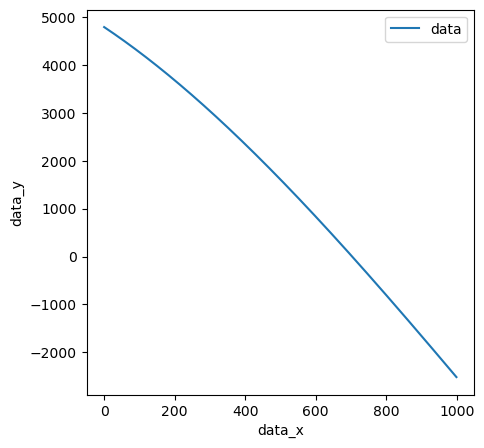

Residual SE: 1015.314
Mean SE: 1028801.126
Linear Div: 818049.970
Standard Div: 2356.109
Standard Err: 74.507
Determination Coeff: 0.815
Correlation Coeff: 0.903
Concordance Coeff: 0.899


In [24]:
data_x = np.arange(0, 1000)
coeffs_poly = [4785.5, -4.9093, -0.0034, 10**-6]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)

ff.multi_plot(ff.PlotRequest(data_ideal,"data"))
print(ff.get_metrics(ff.apply_noise(data_ideal, ff.NoiseConfig(0, 1000)),data_ideal))

## Use normal DSB

Polynomial model rank was raised to: 4
The balance was formed:


4785.5 - a0

-H*a1*a2 - 4.90930000000001*H

H**2*a0*a1**2/2 - 0.00339999999999996*H**2

9.99999999999972e-7*H**3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.78550000e+03 -1.19203991e-03  4.11840238e+03]'

'Metrics:'

Residual SE: 166.205
Mean SE: 27568.949
Linear Div: 104856.257
Standard Div: 2025.400
Standard Err: 64.049
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


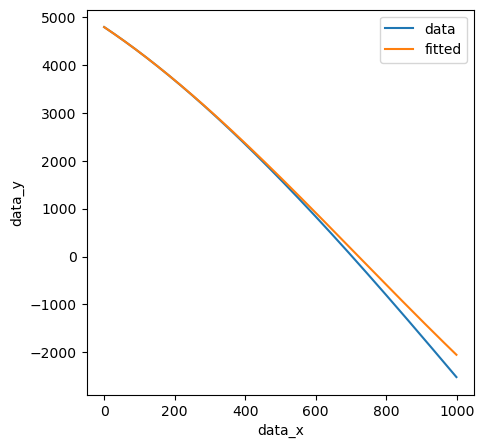

In [ ]:
model = ff.Models.transcendental(ff.FittingModes.DSB)
model.options.echo_on = True
model.options.raise_rank = True
model.options.numeric_optimize = False
model_fitted = model.fit(data_ideal)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

Polynomial model rank remains at: 3
The balance was formed:


4851.59837673647 - a0

-H*a1*a2 - 5.51396250032101*H

H**2*a0*a1**2/2 - 0.00196144276344179*H**2

Solution was found:


...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.851598e+03 -8.992085e-04  6.132018e+03]'

'Metrics:'

Residual SE: 166.205
Mean SE: 27568.949
Linear Div: 104856.257
Standard Div: 2025.400
Standard Err: 64.049
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


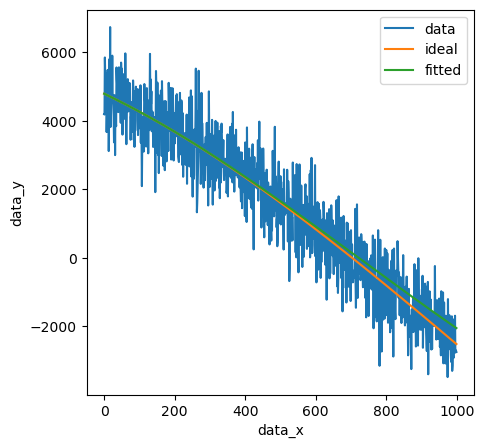

In [ ]:
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use coeffs calculated in Maple

'Metrics:'

Residual SE: 165.209
Mean SE: 27239.475
Linear Div: 104005.450
Standard Div: 2026.041
Standard Err: 64.069
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


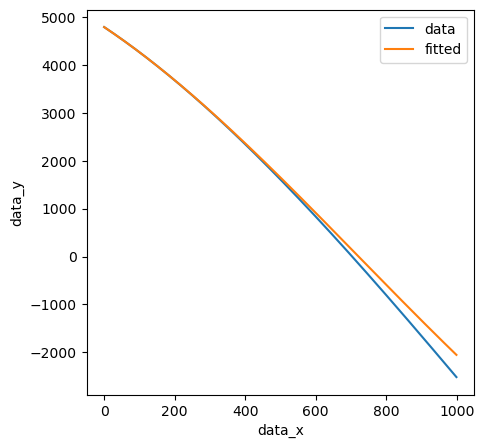

In [ ]:
maple_coeffs = [4785.499998, 0.001192750974, -4115.942072]
def maple_model(x: float) -> float:
    return maple_coeffs[0] * np.cos(maple_coeffs[1] * x) + maple_coeffs[2] * np.sin(maple_coeffs[1] * x)

data_fitted = np.zeros(data_x.size)
for i in np.arange(data_x.size):
    data_fitted[i] = maple_model(data_x[i])

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

## Use programmatic DSBI

Pre-balance was formed:


4785.5 - a0

-H*a1*a2 - 4.90930000000001*H

H**2*a0*a1**2/2 - 0.00339999999999996*H**2

9.99999999999972e-7*H**3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.7855000e+03 -1.1917765e-03  4.1193135e+03]'

'Metrics:'

Residual SE: 166.566
Mean SE: 27688.622
Linear Div: 105163.154
Standard Div: 2025.168
Standard Err: 64.041
Determination Coeff: 0.993
Correlation Coeff: 1.000
Concordance Coeff: 0.998


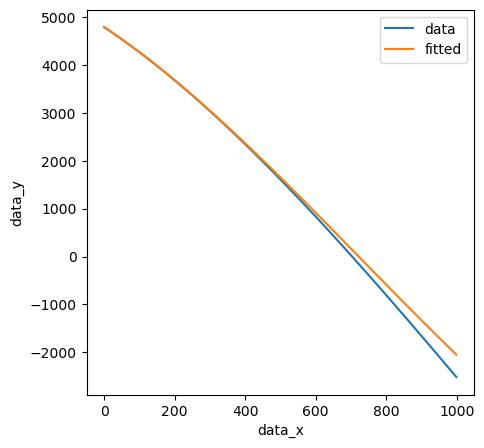

In [ ]:
model = ff.Models.transcendental(ff.FittingModes.DSBI)
model.options.echo_on = True
model.options.numeric_optimize = False
model.options.rank = 4
model.options.dsbi_h = 1.002
model_fitted = model.fit(data_ideal)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_ideal,"data"),
              ff.PlotRequest(data_fitted,"fitted"))

Pre-balance was formed:


4773.09835767002 - a0

-H*a1*a2 - 4.3491315358126*H

H**2*a0*a1**2/2 - 0.00565323258696879*H**2

2.8885564048938e-6*H**3

...

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.7730981e+03 -1.5384960e-03  2.8268733e+03]'

'Metrics:'

Residual SE: 166.059
Mean SE: 27520.454
Linear Div: 132225.257
Standard Div: 2242.608
Standard Err: 70.917
Determination Coeff: 0.995
Correlation Coeff: 1.000
Concordance Coeff: 0.997


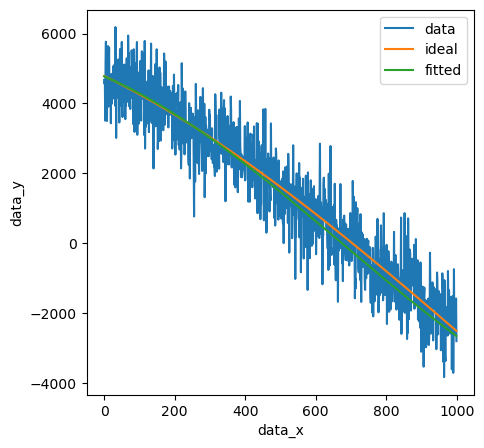

In [ ]:
data_train = ff.apply_noise(data_ideal)
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")

display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(ff.PlotRequest(data_train,"data"),
              ff.PlotRequest(data_ideal,"ideal"),
              ff.PlotRequest(data_fitted,"fitted"))